In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare

In [2]:
def outcome(pred_base, pred_weighted, label, mode="2class"):
    """
    Compare baseline and weighted model predictions using a given evaluation mode.
    mode: one of {"regression", "7class", "5class", "2class", "2class_non0"}
    """

    if mode == "7class":
        base_correct = int(np.clip(pred_base, -3, 3)) == int(np.clip(label, -3, 3))
        weighted_correct = int(np.clip(pred_weighted, -3, 3)) == int(np.clip(label, -3, 3))

    elif mode == "5class":
        base_correct = int(np.clip(pred_base, -2, 2)) == int(np.clip(label, -2, 2))
        weighted_correct = int(np.clip(pred_weighted, -2, 2)) == int(np.clip(label, -2, 2))

    elif mode == "2class":
        base_correct = (pred_base >= 0) == (label >= 0)
        weighted_correct = (pred_weighted >= 0) == (label >= 0)

    elif mode == "2class_non0":
        if label == 0:
            return "ignore"
        base_correct = (pred_base > 0) == (label > 0)
        weighted_correct = (pred_weighted > 0) == (label > 0)

    else:
        raise ValueError("Unknown mode")

    if not base_correct and weighted_correct:
        return "corrected"
    elif base_correct and not weighted_correct:
        return "regressed"
    elif base_correct and weighted_correct:
        return "both_correct"
    else:
        return "both_wrong"


In [3]:
import ast

def to_float(x):
    if isinstance(x, float) or isinstance(x, int):
        return float(x)
    elif isinstance(x, list):
        return float(x[0])
    elif isinstance(x, str) and x.startswith("["):
        try:
            return float(ast.literal_eval(x)[0])
        except:
            return float('nan')
    else:
        return float(x)

In [4]:
def run_outcome_analysis(root_path, paths, dataset, model_base='baseline', model_weighted='KL'):
    # Load CSVs
    runs = {}
    for run_name, path in paths.items():
        df_train = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_train_results.csv')
        df_dev   = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_dev_results.csv')
        df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_test_results.csv')

        #df_train["split"] = "train"
        #df_dev["split"]   = "dev"
        df_test["split"]  = "test"

        runs[run_name] = pd.concat([df_test], ignore_index=True)

    # Merge base and weighted runs
    merged = runs[model_base].merge(runs[model_weighted], on='ids', suffixes=(f'_{model_base}', f'_{model_weighted}'))

    # Keep a consistent GT and split column
    merged['Ground_Truth'] = merged[f'Ground_Truth_{model_base}']
    assert (merged[f'split_{model_base}'] == merged[f'split_{model_weighted}']).all()
    merged['split'] = merged[f'split_{model_base}']

    # Convert to float
    for col in [f'Predicted_{model_base}', f'Predicted_{model_weighted}', 'Ground_Truth']:
        merged[col] = merged[col].apply(to_float)

    # Classification-style outcome labeling
    modes = ["7class", "5class", "2class", "2class_non0"]
    for mode in modes:
        merged[f'outcome_{mode}'] = merged.apply(
            lambda r: outcome(r[f'Predicted_{model_base}'], r[f'Predicted_{model_weighted}'], r['Ground_Truth'], mode),
            axis=1
        )

    # Regression error analysis
    regression_df = merged[["ids", "split", f'Predicted_{model_base}', f'Predicted_{model_weighted}', "Ground_Truth"]].copy()
    regression_df["err_baseline"] = abs(regression_df[f'Predicted_{model_base}'] - regression_df["Ground_Truth"])
    regression_df["err_weighted"] = abs(regression_df[f'Predicted_{model_weighted}'] - regression_df["Ground_Truth"])
    regression_df["delta_err"] = regression_df["err_weighted"] - regression_df["err_baseline"]

    # Print summary for classification modes
    summary = {}
    for mode in modes:
        counts = merged[f'outcome_{mode}'].value_counts()
        summary[mode] = {
            'corrected': counts.get('corrected', 0),
            'regressed': counts.get('regressed', 0),
            'both_correct': counts.get('both_correct', 0),
            'both_wrong': counts.get('both_wrong', 0),
            'net_gain': counts.get('corrected', 0) - counts.get('regressed', 0)
        }

    print(pd.DataFrame(summary).T)
    print("\nRegression ΔError (weighted - baseline):")
    print(regression_df["delta_err"].describe())

    return merged, regression_df


# Local Residual KL

In [5]:
root_path = "/data/wang/junh/results/MMIM/"
paths = {
    "baseline":  "final/noWeights",
    "KL":        "final/error_kl",
    "KL+CC":     "final/error_kl_cc",
    "KL+MI":     "final/error_kl_mi",
}

In [6]:
dataset = "mosi"
merged_mosi_kl, regression_mosi_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             115        105           242         224        10
5class             116        106           247         217        10
2class              45         27           528          86        18
2class_non0         39         27           524          66        12

Regression ΔError (weighted - baseline):
count    686.000000
mean      -0.015413
std        0.576201
min       -3.837650
25%       -0.271776
50%        0.000052
75%        0.299839
max        2.906250
Name: delta_err, dtype: float64


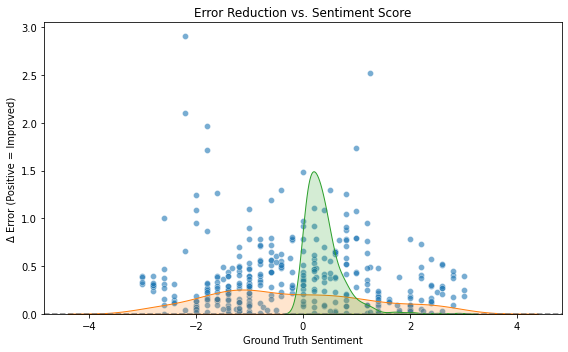

In [7]:
corrected_reg = regression_mosi_kl[regression_mosi_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [8]:
dataset = "mosei"
merged_mosei_kl, regression_mosei_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             333        322          2601        1403        11
5class             333        322          2601        1403        11
2class             638        247          3276         498       391
2class_non0        327        234          2756         317        93

Regression ΔError (weighted - baseline):
count    4659.000000
mean       -0.014984
std         0.371631
min        -2.601375
25%        -0.192506
50%        -0.015031
75%         0.158263
max         2.669665
Name: delta_err, dtype: float64


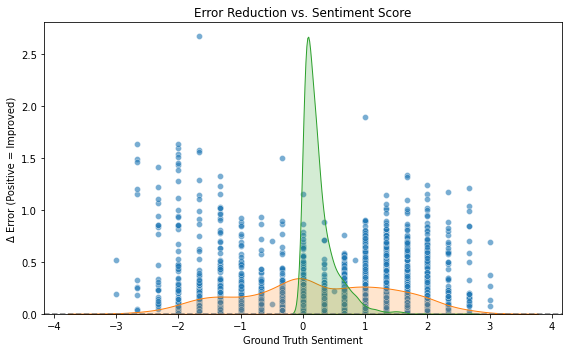

In [9]:
corrected_reg = regression_mosei_kl[regression_mosei_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [10]:
dataset = "mosi"
merged_mosi_kl_cc, regression_mosi_kl_cc = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              62         76           271         277       -14
5class              62         76           277         271       -14
2class              32         19           536          99        13
2class_non0         27         19           532          78         8

Regression ΔError (weighted - baseline):
count    686.000000
mean      -0.018115
std        0.492031
min       -3.353080
25%       -0.208415
50%       -0.010312
75%        0.192034
max        3.145380
Name: delta_err, dtype: float64


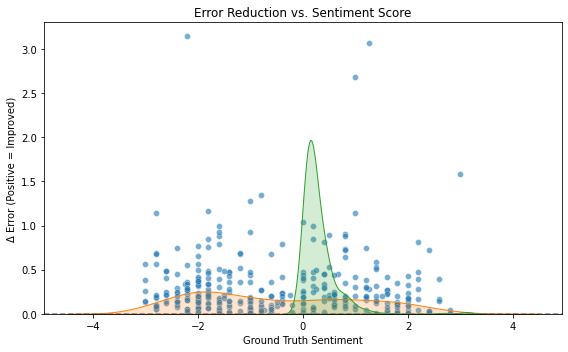

In [11]:
corrected_reg = regression_mosi_kl_cc[regression_mosi_kl_cc["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [12]:
dataset = "mosei"
merged_mosei_kl_cc, regression_mosei_kl_cc  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             300        269          2654        1436        31
5class             300        269          2654        1436        31
2class             780        422          3101         356       358
2class_non0        381        417          2573         263       -36

Regression ΔError (weighted - baseline):
count    4659.000000
mean       -0.016149
std         0.366003
min        -2.658923
25%        -0.182230
50%        -0.008013
75%         0.156064
max         1.888973
Name: delta_err, dtype: float64


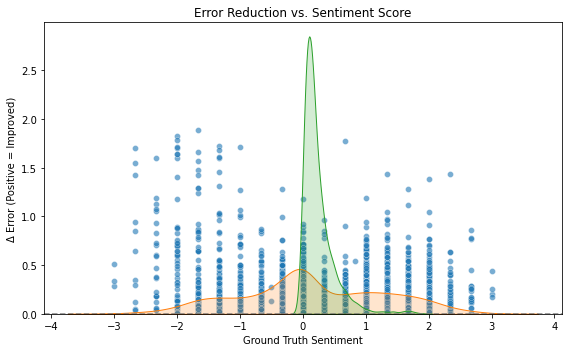

In [13]:
corrected_reg = regression_mosei_kl_cc[regression_mosei_kl_cc["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [14]:
dataset = "mosi"
merged_mosi_kl_mi, regression_mosi_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              75         74           273         264         1
5class              75         75           278         258         0
2class              28         28           527         103         0
2class_non0         24         25           526          81        -1

Regression ΔError (weighted - baseline):
count    686.000000
mean      -0.006877
std        0.521450
min       -3.649393
25%       -0.204946
50%       -0.017809
75%        0.185482
max        3.698015
Name: delta_err, dtype: float64


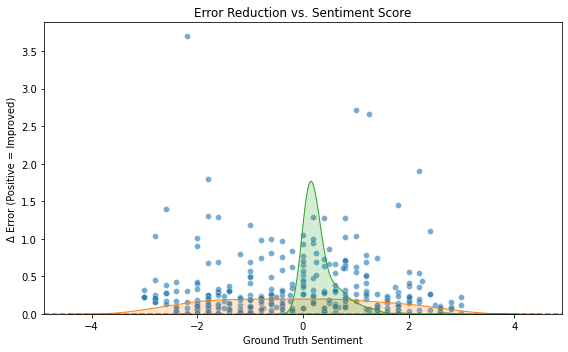

In [15]:
corrected_reg = regression_mosi_kl_mi[regression_mosi_kl_mi["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [16]:
dataset = "mosei"
merged_mosei_kl_mi, regression_mosei_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             284        268          2655        1452        16
5class             284        268          2655        1452        16
2class             541        250          3273         595       291
2class_non0        306        217          2773         338        89

Regression ΔError (weighted - baseline):
count    4659.000000
mean       -0.011960
std         0.353100
min        -2.557610
25%        -0.157000
50%        -0.008809
75%         0.134855
max         2.753389
Name: delta_err, dtype: float64


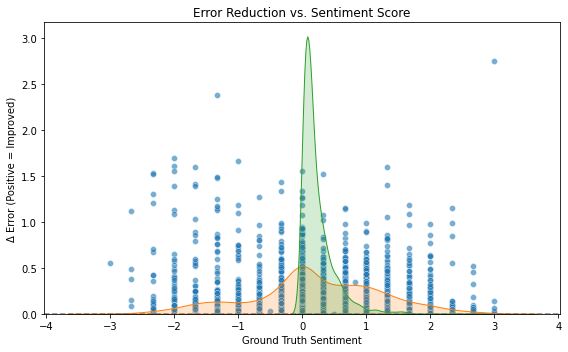

In [17]:
corrected_reg = regression_mosei_kl_mi[regression_mosei_kl_mi["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)

plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [18]:
merged_mosei_kl_mi

,ids,Predicted_baseline,Ground_Truth_baseline,std_baseline,split_baseline,Predicted_KL+MI,Ground_Truth_KL+MI,std_KL+MI,split_KL+MI,Ground_Truth,split,outcome_7class,outcome_5class,outcome_2class,outcome_2class_non0
0,-AUZQgSxyPQ[2],1.376736,[0.6666667],[-0.7100695],test,1.632818,[0.6666667],[-0.9661508],test,0.666667,test,both_wrong,both_wrong,both_correct,both_correct
1,-6rXp3zJ3kc[8],-0.134274,[-1.0],[-0.8657259],test,-0.552438,[-1.0],[-0.44756216],test,-1.000000,test,both_wrong,both_wrong,both_correct,both_correct
2,-6rXp3zJ3kc[9],0.746428,[0.33333334],[-0.41309443],test,0.534923,[0.33333334],[-0.20158955],test,0.333333,test,both_correct,both_correct,both_correct,both_correct
3,-MeTTeMJBNc[7],0.229145,[1.3333334],[1.1041878],test,0.724024,[1.3333334],[0.60930973],test,1.333333,test,both_wrong,both_wrong,both_correct,both_correct
4,-RfYyzHpjk4[9],1.122243,[0.0],[-1.1222426],test,1.136576,[0.0],[-1.1365759],test,0.000000,test,both_wrong,both_wrong,both_correct,ignore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4654,zhNksSReaQk[15],-0.048326,[0.0],[0.048325658],test,0.778073,[0.0],[-0.7780735],test,0.000000,test,both_correct,both_correct,corrected,ignore
4655,zhNksSReaQk[18],0.211122,[0.0],[-0.21112235],test,0.352075,[0.0],[-0.3520749],test,0.000000,test,both_correct,both_correct,both_correct,ignore
4656,zhNksSReaQk[30],-0.648151,[-0.6666667],[-0.018515885],test,-0.895937,[-0.6666667],[0.22927052],test,-0.666667,test,both_correct,both_correct,both_correct,both_correct
4657,zhNksSReaQk[8],0.028858,[0.0],[-0.028858155],test,0.184089,[0.0],[-0.18408862],test,0.000000,test,both_correct,both_correct,both_correct,ignore
